In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Change this to switch language ----
langCode = "deu"
# -----------------------------------------

# Look up language name automatically
shortcuts = pd.read_csv("../../src/0_data_processing/corpora/leipzig/lepzig_shortcuts.csv")
langName = shortcuts.loc[shortcuts["code"] == langCode, "language"].values[0]

# Load CSV
df = pd.read_csv(f"../../data/1_aggregated/{langCode}.csv")

# Sort by frequency descending, just in case
df = df.sort_values("frequency", ascending=False).reset_index(drop=True)

# Add rank
df["rank"] = df.index + 1

# Cumulative corpus coverage
df["cumFreq"] = df["frequency"].cumsum()
totalFreq = df["frequency"].sum()
df["coverage"] = df["cumFreq"] / totalFreq

ranks = df["rank"].to_numpy()
freqs = df["frequency"].to_numpy()
probs = freqs / totalFreq

print(f"Total frequency: {totalFreq}")


Total frequency: 8846049483


In [2]:

# Two sets of cutoffs: "light" and "dark"
cutoffs = {
    "light": {"freq": 100, "rankShare": 0.05, "coverage": 0.95},
    "dark":  {"freq": 10,  "rankShare": 0.30, "coverage": 0.99},
}

results = {}

for label, c in cutoffs.items():
    res = {}

    # 1) Red: frequency cutoff → probability cutoff
    freqThresh = c["freq"]
    probThresh = freqThresh / totalFreq
    redX = None
    for i in range(len(probs) - 1):
        y1, y2 = probs[i], probs[i + 1]
        if y1 >= probThresh >= y2:
            x1, x2 = ranks[i], ranks[i + 1]
            if y1 == y2:
                redX = x1
            else:
                redX = x1 + (probThresh - y1) * (x2 - x1) / (y2 - y1)
            break
    if redX is None:
        redX = ranks[-1] if probs[-1] > probThresh else ranks[0]
    res["redX"] = redX
    res["redY"] = probThresh

    # 2) Blue: rank share cutoff
    blueX = c["rankShare"] * len(df)
    blueY = np.interp(blueX, ranks, probs)
    res["blueX"] = blueX
    res["blueY"] = blueY

    # 3) Green: corpus coverage cutoff
    greenIndex = np.argmax(df["coverage"].to_numpy() >= c["coverage"])
    greenX = ranks[greenIndex]
    greenY = probs[greenIndex]
    res["greenIndex"] = greenIndex
    res["greenX"] = greenX
    res["greenY"] = greenY


    results[label] = res

C:\Users\Tonda\AppData\Local\Temp\ipykernel_16344\4052263808.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


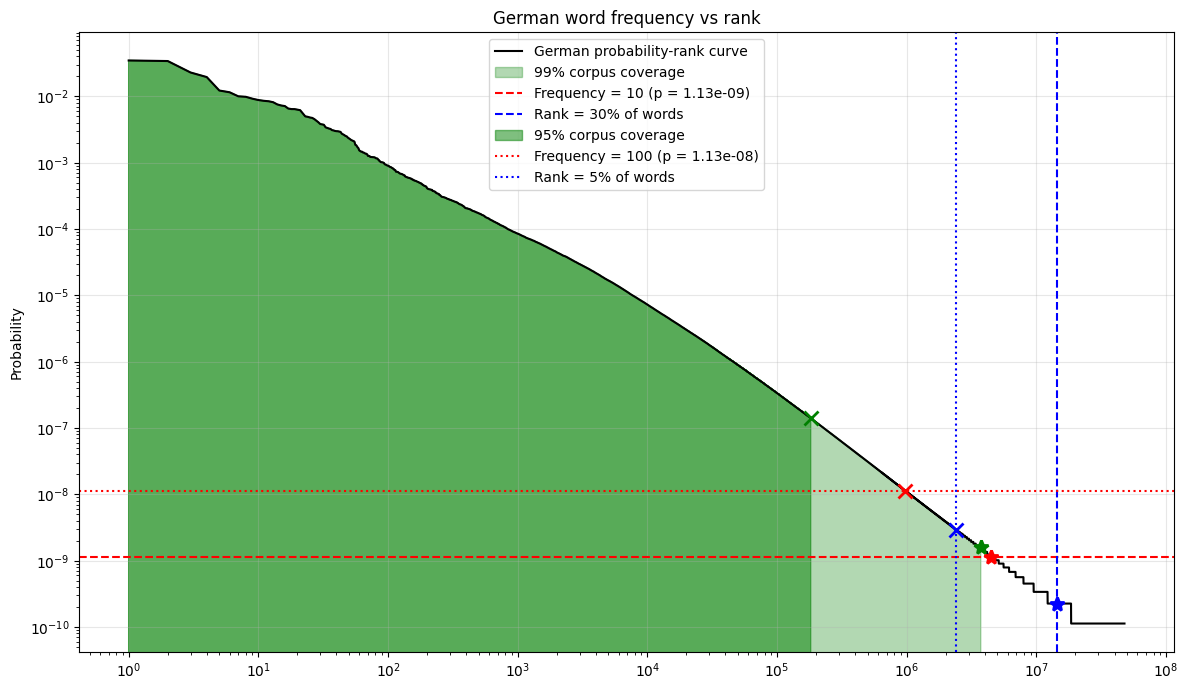


[LIGHT]
  Red cross   (freq = 100): rank ≈ 972273.00
  Blue cross  (rank = 5% of words): rank = 2387199.85, freq ≈ 0.00
  Green cross (95% coverage): rank = 181720, freq = 1.4085383564658047e-07, words = 181720 (0.38% of vocabulary)

[DARK]
  Red cross   (freq = 10): rank ≈ 4428798.00
  Blue cross  (rank = 30% of words): rank = 14323199.10, freq ≈ 0.00
  Green cross (99% coverage): rank = 3722308, freq = 1.5826273668155108e-09, words = 3722308 (7.80% of vocabulary)


In [ ]:

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 7))

# Main probability-rank curve
plt.plot(ranks, probs, color="black", label=f"{langName} probability-rank curve")

# Style per set
styles = {
    "light": {"ls": ":", "marker": "x", "fill_alpha": 0.50, "fill_color": "green"},
    "dark":  {"ls": "--", "marker": "*", "fill_alpha": 0.30, "fill_color": "green"},
}

for label in ["dark", "light"]:  # draw dark (99%) first so light (95%) overlaps on top
    c = cutoffs[label]
    r = results[label]
    s = styles[label]

    # Green filled area – corpus coverage
    idx = r["greenIndex"]
    plt.fill_between(
        ranks[:idx + 1],
        probs[:idx + 1],
        color=s["fill_color"],
        alpha=s["fill_alpha"],
        label=f"{int(c['coverage'] * 100)}% corpus coverage",
    )

    # Red horizontal line – probability cutoff
    probThresh = c["freq"] / totalFreq
    plt.axhline(
        y=probThresh, color="red", linestyle=s["ls"],
        label=f"Frequency = {c['freq']} (p = {probThresh:.2e})",
    )
    plt.plot(r["redX"], r["redY"], marker=s["marker"], color="red", markersize=10, mew=2)

    # Blue vertical line – rank share cutoff
    plt.axvline(
        x=r["blueX"], color="blue", linestyle=s["ls"],
        label=f"Rank = {int(c['rankShare'] * 100)}% of words",
    )
    plt.plot(r["blueX"], r["blueY"], marker=s["marker"], color="blue", markersize=10, mew=2)

    # Green marker at coverage boundary
    plt.plot(r["greenX"], r["greenY"], marker=s["marker"], color="green", markersize=10, mew=2)

plt.xscale("log")
plt.yscale("log")
plt.ylabel("Probability")
plt.title(f"{langName} word probability vs rank")
plt.title(f\"{langName} word probability vs rank\")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Print exact values for both sets
for label in ["light", "dark"]:
    c = cutoffs[label]
    r = results[label]
    print(f"\n[{label.upper()}]")
    print(f"  Red cross   (freq = {c['freq']}): rank ≈ {r['redX']:.2f}")
    print(f"  Blue cross  (rank = {int(c['rankShare']*100)}% of words): rank = {r['blueX']:.2f}, freq ≈ {r['blueY']:.2f}")
    pct = r['greenIndex'] + 1  # number of words for coverage
    print(f"  Green cross ({int(c['coverage']*100)}% coverage): rank = {r['greenX']}, freq = {r['greenY']}, words = {pct} ({pct / len(df) * 100:.2f}% of vocabulary)")
